# Vlasov Two-Stream LaSDI-NM Example (ConvAE / FlatAE)


In [61]:
import re
import time
from pathlib import Path

import numpy as np
import numpy.linalg as LA

import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import modLaSDIUtils as lasdiutils
import modAutoEncoder as autoencoder
from ConvAE import ConvEncoder, ConvDecoder, get_activation
from LaSDI import LaSDI
from scipy.interpolate import Rbf, interp2d


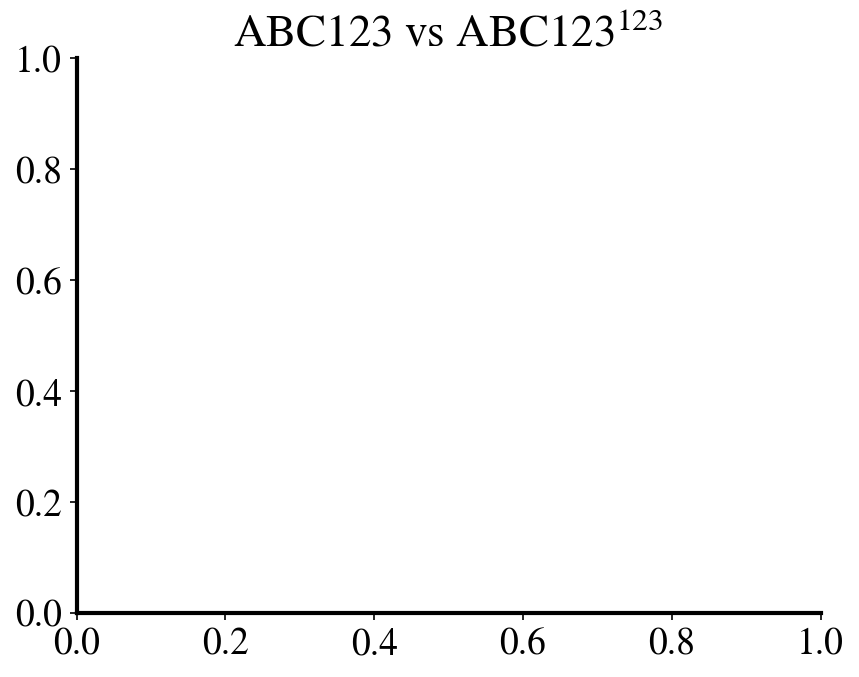

In [62]:
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.pyplot.title(r'ABC123 vs $\mathrm{ABC123}^{123}$')
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['lines.markersize'] = 8
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['figure.dpi'] = 150


In [63]:
torch.cuda.empty_cache()
device = autoencoder.getDevice()
print(f'Using device: {device}')
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


### Load Vlasov dataset and trained AE model (ConvAE or FlatAE)


In [64]:
dataset_root = Path('./vlasov_twostream_param_grid')

# Priority order: first existing file is used.
model_candidates = [
    Path('./models/conv_ae_latent6/AE_vlasov.tar'),
    Path('./models/flat_ae_latent5_ep1500/AE_vlasov.tar'),
    #Path('./models/flat_single_ae_spa5_ep200/AE_vlasov.tar'),
    Path('./models/AE_vlasov_smoke.tar'),
    Path('./models/AE_vlasov_smoke2.tar'),
]

# Optional manual override: None / 'convae' / 'flatae'
model_kind_override = None

existing_models = [p for p in model_candidates if p.exists()]
if not existing_models:
    raise FileNotFoundError('No AE model/checkpoint found in expected paths.')
model_file = existing_models[0]

# LaSDI training/evaluation setup
samples_per_axis = 4
poly_degree = 2
include_interaction = True
sindy_threshold = 0.01

# Activation used in AE training (default: swish)
activation_name = 'swish'  # 'swish' or 'sigmoid'

# Single-case visualization target: [T, k]
eval_param = np.array([1.00, 1.10], dtype=float)

if not dataset_root.exists():
    raise FileNotFoundError(dataset_root.resolve())

print(f'dataset_root: {dataset_root.resolve()}')
print(f'model_file:   {model_file.resolve()}')


dataset_root: /home/uts22/projects/ML_phisycs/LaSDI/Vlasov_twostream/vlasov_twostream_param_grid
model_file:   /home/uts22/projects/ML_phisycs/LaSDI/Vlasov_twostream/models/conv_ae_latent6/AE_vlasov.tar


In [65]:
sample_case = sorted(dataset_root.glob('T_*_k_*'))[0]
with np.load(sample_case / 'distribution_full.npz') as data:
    f_sample = np.asarray(data['f'], dtype=np.float32)
    t = np.asarray(data['t'], dtype=float)
    x = np.asarray(data['x'], dtype=float)
    v = np.asarray(data['v'], dtype=float)

nt = f_sample.shape[0] - 1
Nx = f_sample.shape[1]
Nv = f_sample.shape[2]
dt = float(t[1] - t[0])

state = torch.load(model_file, map_location='cpu')
if 'encoder_state_dict' not in state or 'decoder_state_dict' not in state:
    raise ValueError(f'Invalid model/checkpoint format: {model_file}')

enc_state = state['encoder_state_dict']
dec_state = state['decoder_state_dict']


def detect_model_kind(enc_sd, override=None):
    if override is not None:
        ov = str(override).lower()
        if ov not in {'convae', 'flatae'}:
            raise ValueError("model_kind_override must be None/'convae'/'flatae'")
        return ov
    if 'fc.3.weight' in enc_sd:
        return 'convae'
    if 'full.0.weight' in enc_sd and 'full.2.weight' in enc_sd:
        return 'flatae'
    raise ValueError('Unable to detect model kind from state_dict keys.')


model_kind = detect_model_kind(enc_state, model_kind_override)
model_tag = model_kind


# Common helpers (defined after model load)
encode_field_sequence = None
decode_latent_sequence = None
make_lasdi_ic = None

if model_kind == 'convae':
    f_latent = int(enc_state['fc.3.weight'].shape[0])
    activation_cls = get_activation(activation_name)

    encoder = ConvEncoder(latent_dim=f_latent, activation_cls=activation_cls).to(device)
    decoder = ConvDecoder(latent_dim=f_latent, activation_cls=activation_cls).to(device)
    encoder.load_state_dict(enc_state)
    decoder.load_state_dict(dec_state)
    encoder.eval()
    decoder.eval()

    class EncoderForLaSDI(nn.Module):
        def __init__(self, base_encoder):
            super().__init__()
            self.base = base_encoder

        def forward(self, x):
            if x.ndim == 3:
                x = x.unsqueeze(0)
            z = self.base(x)
            if z.ndim == 2 and z.shape[0] == 1:
                return z.squeeze(0)
            return z

    class DecoderForLaSDI(nn.Module):
        def __init__(self, base_decoder):
            super().__init__()
            self.base = base_decoder

        def forward(self, z):
            if z.ndim == 1:
                z = z.unsqueeze(0)
            y = self.base(z)
            return y[:, 0]

    encoder_lasdi = EncoderForLaSDI(encoder).to(device)
    decoder_lasdi = DecoderForLaSDI(decoder).to(device)
    encoder_lasdi.eval()
    decoder_lasdi.eval()

    def encode_field_sequence(f_seq, batch_size=256):
        x = torch.as_tensor(f_seq[:, None, :, :], dtype=torch.float32, device=device)
        out = []
        bs = max(1, int(batch_size))
        with torch.no_grad():
            for i in range(0, x.shape[0], bs):
                out.append(encoder(x[i:i+bs]).cpu().numpy())
        z = np.concatenate(out, axis=0)
        return z.astype(np.float32, copy=False)

    def decode_latent_sequence(z_seq, batch_size=256):
        z = np.asarray(z_seq, dtype=np.float32)
        if z.ndim == 1:
            z = z[None, :]
        zt = torch.as_tensor(z, dtype=torch.float32, device=device)
        out = []
        bs = max(1, int(batch_size))
        with torch.no_grad():
            for i in range(0, zt.shape[0], bs):
                out.append(decoder(zt[i:i+bs])[:, 0].cpu().numpy())
        f = np.concatenate(out, axis=0)
        return f.astype(np.float32, copy=False)

    def make_lasdi_ic(f0):
        return np.asarray(f0[None, :, :], dtype=np.float32)

else:
    if activation_name == 'sigmoid':
        f_activation = nn.Sigmoid
    elif activation_name == 'swish':
        f_activation = autoencoder.SiLU
    else:
        raise ValueError("activation_name must be 'swish' or 'sigmoid'")

    # Recover dimensions from flat AE checkpoint
    if 'full.2.weight_orig' in dec_state:
        m = int(dec_state['full.2.weight_orig'].shape[0])
    elif 'full.2.weight' in dec_state:
        m = int(dec_state['full.2.weight'].shape[0])
    else:
        raise ValueError('FlatAE decoder does not contain full.2 weight information.')

    expected_m = Nx * Nv
    if m != expected_m:
        raise ValueError(f'FlatAE input dim m={m} does not match Nx*Nv={expected_m}')

    M2 = int(dec_state['full.0.weight'].shape[0])
    f_latent = int(enc_state['full.2.weight'].shape[0])
    M1 = int(enc_state['full.0.weight'].shape[0])

    db = 1
    b = M2 - (m - 1) * db
    if b <= 0:
        raise ValueError(f'Invalid derived mask params from model dims: b={b}, db={db}')

    mask = lasdiutils.create_mask_1d(m, b, db)

    encoder, decoder = autoencoder.readAEFromFile(
        autoencoder.Encoder,
        autoencoder.Decoder,
        f_activation,
        mask,
        m,
        f_latent,
        M1,
        M2,
        device,
        str(model_file),
    )
    encoder.eval()
    decoder.eval()

    encoder_lasdi = encoder
    decoder_lasdi = decoder

    def encode_field_sequence(f_seq, batch_size=256):
        flat = np.asarray(f_seq, dtype=np.float32).reshape(f_seq.shape[0], -1)
        x = torch.as_tensor(flat, dtype=torch.float32, device=device)
        out = []
        bs = max(1, int(batch_size))
        with torch.no_grad():
            for i in range(0, x.shape[0], bs):
                z = encoder(x[i:i+bs]).cpu().numpy()
                if z.ndim == 1:
                    z = z[None, :]
                out.append(z)
        z = np.concatenate(out, axis=0)
        return z.astype(np.float32, copy=False)

    def decode_latent_sequence(z_seq, batch_size=256):
        z = np.asarray(z_seq, dtype=np.float32)
        if z.ndim == 1:
            z = z[None, :]
        zt = torch.as_tensor(z, dtype=torch.float32, device=device)
        out = []
        bs = max(1, int(batch_size))
        with torch.no_grad():
            for i in range(0, zt.shape[0], bs):
                y = decoder(zt[i:i+bs]).cpu().numpy()
                if y.ndim == 1:
                    y = y[None, :]
                out.append(y)
        flat = np.concatenate(out, axis=0)
        f = flat.reshape(flat.shape[0], Nx, Nv)
        return f.astype(np.float32, copy=False)

    def make_lasdi_ic(f0):
        return np.asarray(f0, dtype=np.float32).reshape(-1)

print(f'sample case: {sample_case.name}')
print(f'f shape: {f_sample.shape} (Nt+1, Nx, Nv)')
print(f'dt = {dt:.5f}, t in [{t[0]:.3f}, {t[-1]:.3f}], nt = {nt}')
print(f'Model kind: {model_kind}')
print(f'Latent dim: f={f_latent}')


sample case: T_0.90_k_1.00
f shape: (1001, 128, 128) (Nt+1, Nx, Nv)
dt = 0.00500, t in [0.000, 5.000], nt = 1000
Model kind: convae
Latent dim: f=6


### Build latent-space trajectories for LaSDI dynamics training


In [66]:
CASE_NAME_RE = re.compile(r'^T_([-+0-9.eE]+)_k_([-+0-9.eE]+)$')


def discover_cases(root: Path):
    cases = []
    for case_dir in sorted(root.iterdir()):
        if not case_dir.is_dir():
            continue
        match = CASE_NAME_RE.match(case_dir.name)
        if match is None:
            continue
        dist_path = case_dir / 'distribution_full.npz'
        if not dist_path.exists():
            continue
        cases.append(
            {
                'T': float(match.group(1)),
                'k': float(match.group(2)),
                'path': dist_path,
                'name': case_dir.name,
            }
        )
    if not cases:
        raise RuntimeError(f'No valid Vlasov cases found under: {root.resolve()}')
    return cases


def select_cases(cases, samples_per_axis=5):
    if samples_per_axis <= 0:
        return list(cases)

    T_values = np.array(sorted({c['T'] for c in cases}), dtype=float)
    k_values = np.array(sorted({c['k'] for c in cases}), dtype=float)

    if samples_per_axis > len(T_values) or samples_per_axis > len(k_values):
        raise ValueError('samples_per_axis exceeds available T-k grid size')

    T_idx = np.round(np.linspace(0, len(T_values) - 1, samples_per_axis)).astype(int)
    k_idx = np.round(np.linspace(0, len(k_values) - 1, samples_per_axis)).astype(int)
    T_idx = np.asarray(list(dict.fromkeys(T_idx.tolist())), dtype=int)
    k_idx = np.asarray(list(dict.fromkeys(k_idx.tolist())), dtype=int)

    target_pairs = {(float(T_values[i]), float(k_values[j])) for i in T_idx for j in k_idx}
    selected = [c for c in cases if (c['T'], c['k']) in target_pairs]
    selected.sort(key=lambda c: (c['T'], c['k']))

    if not selected:
        raise RuntimeError('No cases selected for dynamics training')
    return selected


all_cases = discover_cases(dataset_root)
train_cases = select_cases(all_cases, samples_per_axis=samples_per_axis)
case_map = {(round(c['T'], 2), round(c['k'], 2)): c for c in all_cases}

print(f'Total cases found: {len(all_cases)}')
print(f'Cases used for LaSDI dynamics: {len(train_cases)}')
print('First 5 training cases:', [c['name'] for c in train_cases[:5]])


Total cases found: 441
Cases used for LaSDI dynamics: 16
First 5 training cases: ['T_0.90_k_1.00', 'T_0.90_k_1.07', 'T_0.90_k_1.13', 'T_0.90_k_1.20', 'T_0.97_k_1.00']


In [67]:
latent_space_SS = []
params = []

for idx, case in enumerate(train_cases, start=1):
    with np.load(case['path']) as data:
        f_case = np.asarray(data['f'], dtype=np.float32)

    if f_case.shape[1] != Nx or f_case.shape[2] != Nv:
        raise ValueError(f"Unexpected spatial shape in {case['path']}: {f_case.shape}")

    f_case = f_case[: nt + 1]
    z_case = encode_field_sequence(f_case, batch_size=256)

    if not np.all(np.isfinite(z_case)):
        raise FloatingPointError(f'Non-finite latent values in {case["name"]}')

    latent_space_SS.append(z_case)
    params.append(np.array([case['T'], case['k']], dtype=float))

    if idx % 5 == 0 or idx == len(train_cases):
        print(f'[latent-{model_tag}] processed {idx}/{len(train_cases)} cases')

P = np.asarray(params, dtype=float)

print(f'latent trajectories: {len(latent_space_SS)}')
print(f'P shape: {P.shape}')


[latent-convae] processed 5/16 cases
[latent-convae] processed 10/16 cases
[latent-convae] processed 15/16 cases
[latent-convae] processed 16/16 cases
latent trajectories: 16
P shape: (16, 2)


### Train LaSDI dynamics model in latent space


In [68]:
def knn_idw_factory(x, y, z, p=2, eps=1e-12):
    pts = np.column_stack([x, y])
    z = np.asarray(z)
    def f(px, py):
        d = np.linalg.norm(pts - np.array([px, py]), axis=1)
        if np.min(d) < eps:
            return z[np.argmin(d)]
        w = 1.0 / (d**p + eps)
        w /= w.sum()
        return np.dot(w, z)
    return f


In [69]:
normal = np.amax(np.abs(np.concatenate(latent_space_SS, axis=0)))
LaSDI_model = LaSDI(encoder_lasdi, decoder_lasdi, 
                    NN=True, device=device,
                    Local=False,
                    Coef_interp=False,
                    #Coef_interp_method=Rbf
                    Coef_interp_method=knn_idw_factory
                    )
LaSDI_model.train_dynamics(
    latent_space_SS,
    P,
    dt,
    degree=poly_degree,
    include_interaction=include_interaction,
    normal=normal,
    LS_vis=False,
    threshold=sindy_threshold,
)


(x0)' = -0.474 1 + -1.072 x0 +  5.479 x1 +  0.719 x2 +  0.472 x3 + -0.670 x4 + -3.324 x5 + -1.049 x0^2 +  3.667 x0 x1 +  0.179 x0 x2 + -0.690 x0 x3 +  1.378 x0 x4 + -3.998 x0 x5 +  4.091 x1^2 + -2.777 x1 x2 +  2.518 x1 x3 +  0.643 x1 x4 + -2.333 x1 x5 +  0.454 x2^2 + -1.240 x2 x3 +  1.326 x2 x4 +  1.683 x2 x5 +  0.311 x3^2 +  0.422 x3 x4 + -1.515 x3 x5 + -0.839 x4^2 +  0.604 x4 x5 + -1.702 x5^2
(x1)' =  1.868 1 + -3.490 x0 + -1.488 x1 + -0.966 x2 +  0.678 x3 +  0.176 x4 +  10.639 x5 + -0.605 x0^2 + -5.416 x0 x1 +  6.475 x0 x2 + -3.521 x0 x3 + -1.612 x0 x4 +  11.579 x0 x5 + -2.866 x1^2 +  3.426 x1 x2 + -4.983 x1 x3 +  3.941 x1 x4 +  5.558 x1 x5 + -0.569 x2^2 +  3.465 x2 x3 + -4.420 x2 x4 + -4.888 x2 x5 + -0.995 x3^2 + -0.952 x3 x4 +  5.688 x3 x5 +  3.632 x4^2 + -3.434 x4 x5 +  5.331 x5^2
(x2)' =  1.233 1 + -1.610 x0 + -0.962 x1 + -1.026 x2 +  0.786 x3 +  0.341 x4 +  4.966 x5 + -0.821 x0^2 + -2.797 x0 x1 +  3.780 x0 x2 + -1.110 x0 x3 + -0.870 x0 x4 +  4.438 x0 x5 + -1.439 x1^2 +  0.956 x

### Reconstruct one Vlasov case and check error history


In [70]:
def reconstruct_case(T, k, time_stride=1):
    key = (round(float(T), 2), round(float(k), 2))
    if key not in case_map:
        raise KeyError(f'Case T={T}, k={k} is not available in dataset')

    with np.load(case_map[key]['path']) as data:
        f_true_full = np.asarray(data['f'], dtype=np.float32)
        t_full = np.asarray(data['t'], dtype=float)
        x_case = np.asarray(data['x'], dtype=float)
        v_case = np.asarray(data['v'], dtype=float)

    stride = max(1, int(time_stride))
    time_indices = np.arange(0, len(t_full), stride, dtype=int)
    t_eval = t_full[time_indices]

    f_true = f_true_full[time_indices]
    pred_ic = make_lasdi_ic(f_true_full[0])

    param = np.array([float(T), float(k)], dtype=float)
    pred_out = LaSDI_model.generate_ROM(pred_ic, param, t_eval)
    pred_out = np.asarray(pred_out, dtype=np.float32)

    if model_kind == 'flatae':
        if pred_out.ndim == 1:
            pred_out = pred_out[None, :]
        if pred_out.ndim != 2:
            raise ValueError(f'Unexpected FlatAE prediction shape: {pred_out.shape}')
        f_pred = pred_out.reshape(pred_out.shape[0], Nx, Nv)
    else:
        if pred_out.ndim == 4 and pred_out.shape[1] == 1:
            pred_out = pred_out[:, 0]
        if pred_out.ndim != 3:
            raise ValueError(f'Unexpected ConvAE prediction shape: {pred_out.shape}')
        f_pred = pred_out

    if not np.all(np.isfinite(f_pred)):
        raise FloatingPointError(
            f'Non-finite ROM prediction for T={float(T):.2f}, k={float(k):.2f}. '
            'SINDy rollout likely diverged.'
        )

    n_t = min(f_true.shape[0], f_pred.shape[0])
    f_true = f_true[:n_t]
    t_eval = t_eval[:n_t]
    f_pred = f_pred[:n_t]

    true_flat = f_true.reshape(n_t, -1)
    pred_flat = f_pred.reshape(n_t, -1)
    denom = np.maximum(np.linalg.norm(true_flat, axis=1), 1.0e-12)
    rel_t = np.linalg.norm(pred_flat - true_flat, axis=1) / denom

    return {
        'T': float(T),
        'k': float(k),
        't': t_eval,
        'x': x_case,
        'v': v_case,
        'f_true': f_true,
        'f_pred': f_pred,
        'rel_t': rel_t,
    }


start = time.time()
result_eval = reconstruct_case(eval_param[0], eval_param[1], time_stride=1)
recon_time = time.time() - start

print(f"Reconstruction finished in {recon_time:.2f} s for T={result_eval['T']:.2f}, k={result_eval['k']:.2f}")
print(f"Max relative error: {100.0 * np.max(result_eval['rel_t']):.3f}%")


Reconstruction finished in 2.45 s for T=1.00, k=1.10
Max relative error: 11.572%


In [71]:
"""
from itertools import combinations_with_replacement
import numpy as np

def _term_names(n_state, degree):
    names = []
    for d in range(1, degree + 1):
        for idxs in combinations_with_replacement(range(n_state), d):
            names.append("*".join([f"x{i}" for i in idxs]))
    return ["1"] + names

# まずこのパラメータで一度ROMを計算して coeff_interp_model を作る
_ = reconstruct_case(1.00, 1.10, time_stride=1)

# LaSDI.py の ODE_resim と同じ向きに合わせる
Xi = LaSDI_model.coeff_interp_model.T   # shape: (n_terms, n_state)
terms = _term_names(Xi.shape[1], LaSDI_model.degree)

for j in range(Xi.shape[1]):
    parts = [f"{Xi[i, j]:+.4e}*{terms[i]}" for i in range(Xi.shape[0]) if abs(Xi[i, j]) > 1e-12]
    rhs = " ".join(parts) if parts else "0"
    print(f"(x{j})' = {rhs}")
"""


'\nfrom itertools import combinations_with_replacement\nimport numpy as np\n\ndef _term_names(n_state, degree):\n    names = []\n    for d in range(1, degree + 1):\n        for idxs in combinations_with_replacement(range(n_state), d):\n            names.append("*".join([f"x{i}" for i in idxs]))\n    return ["1"] + names\n\n# まずこのパラメータで一度ROMを計算して coeff_interp_model を作る\n_ = reconstruct_case(1.00, 1.10, time_stride=1)\n\n# LaSDI.py の ODE_resim と同じ向きに合わせる\nXi = LaSDI_model.coeff_interp_model.T   # shape: (n_terms, n_state)\nterms = _term_names(Xi.shape[1], LaSDI_model.degree)\n\nfor j in range(Xi.shape[1]):\n    parts = [f"{Xi[i, j]:+.4e}*{terms[i]}" for i in range(Xi.shape[0]) if abs(Xi[i, j]) > 1e-12]\n    rhs = " ".join(parts) if parts else "0"\n    print(f"(x{j})\' = {rhs}")\n'

### Latent-space dynamics comparison (prediction vs encoded ground truth)


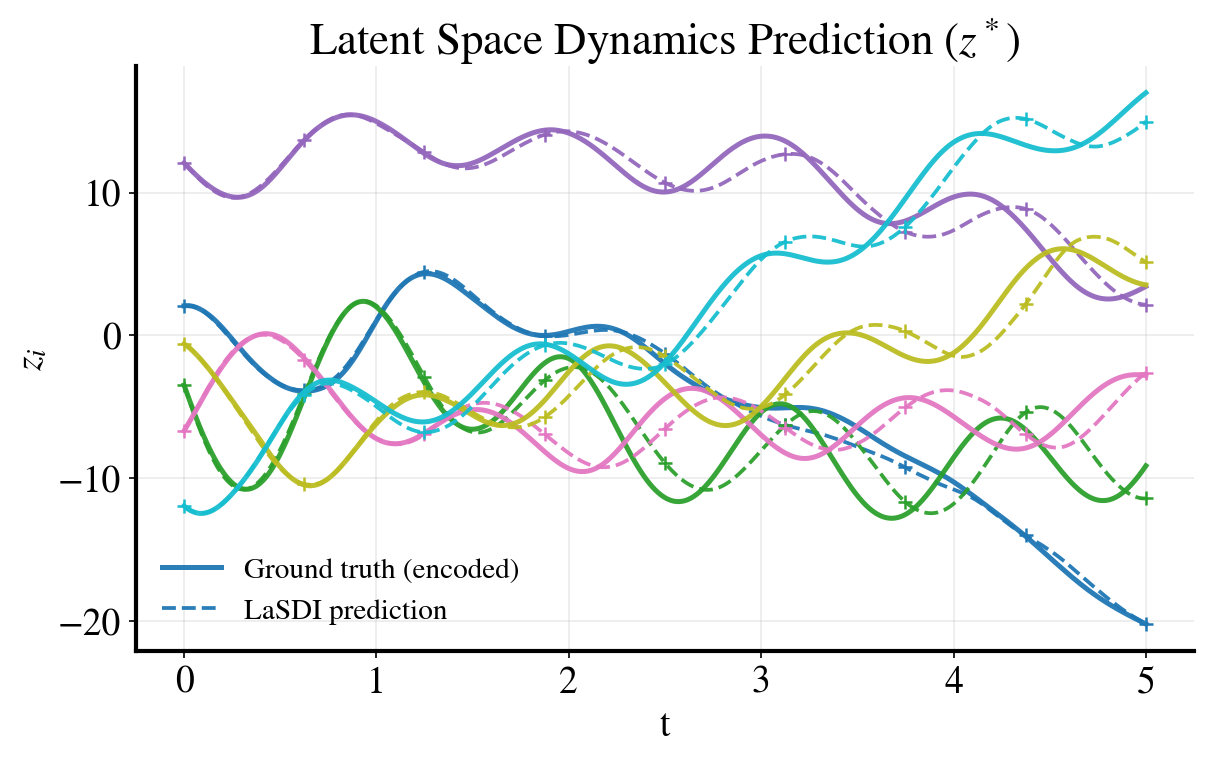

Saved latent comparison image to: /home/uts22/projects/ML_phisycs/LaSDI/Vlasov_twostream/results/latent_dynamics_compare_T1.00_k1.10_convae.png
Saved latent comparison data  to: /home/uts22/projects/ML_phisycs/LaSDI/Vlasov_twostream/results/latent_dynamics_compare_T1.00_k1.10_convae.npz


In [72]:
n_t_eval = result_eval['t'].shape[0]

z_true = encode_field_sequence(result_eval['f_true'], batch_size=256)
z_pred = encode_field_sequence(result_eval['f_pred'], batch_size=256)

n_dims_plot = min(8, z_true.shape[1])
colors = plt.cm.tab10(np.linspace(0.0, 1.0, n_dims_plot))

fig, ax = plt.subplots(figsize=(8.4, 5.4))
for dim in range(n_dims_plot):
    ax.plot(
        result_eval['t'],
        z_true[:, dim],
        color=colors[dim],
        lw=2.4,
        alpha=0.95,
        label='Ground truth (encoded)' if dim == 0 else '_nolegend_',
    )
    ax.plot(
        result_eval['t'],
        z_pred[:, dim],
        '--',
        color=colors[dim],
        lw=1.8,
        alpha=0.95,
        label='LaSDI prediction' if dim == 0 else '_nolegend_',
    )

    marker_step = max(1, n_t_eval // 8)
    ax.plot(
        result_eval['t'][::marker_step],
        z_pred[::marker_step, dim],
        linestyle='None',
        marker='+',
        markersize=7,
        markeredgewidth=1.2,
        color=colors[dim],
        label='_nolegend_',
    )

ax.set_title(r'Latent Space Dynamics Prediction ($z^*$)')
ax.set_xlabel('t')
ax.set_ylabel(r'$z_i$')
ax.grid(alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()

out_dir = Path('results')
out_dir.mkdir(parents=True, exist_ok=True)
out_img = out_dir / f"latent_dynamics_compare_T{result_eval['T']:.2f}_k{result_eval['k']:.2f}_{model_tag}.png"
out_npz = out_dir / f"latent_dynamics_compare_T{result_eval['T']:.2f}_k{result_eval['k']:.2f}_{model_tag}.npz"
fig.savefig(out_img, dpi=300)
np.savez(
    out_npz,
    t=result_eval['t'],
    z_true=z_true,
    z_pred=z_pred,
    T=np.array([result_eval['T']], dtype=float),
    k=np.array([result_eval['k']], dtype=float),
)
plt.show()

print(f'Saved latent comparison image to: {out_img.resolve()}')
print(f'Saved latent comparison data  to: {out_npz.resolve()}')


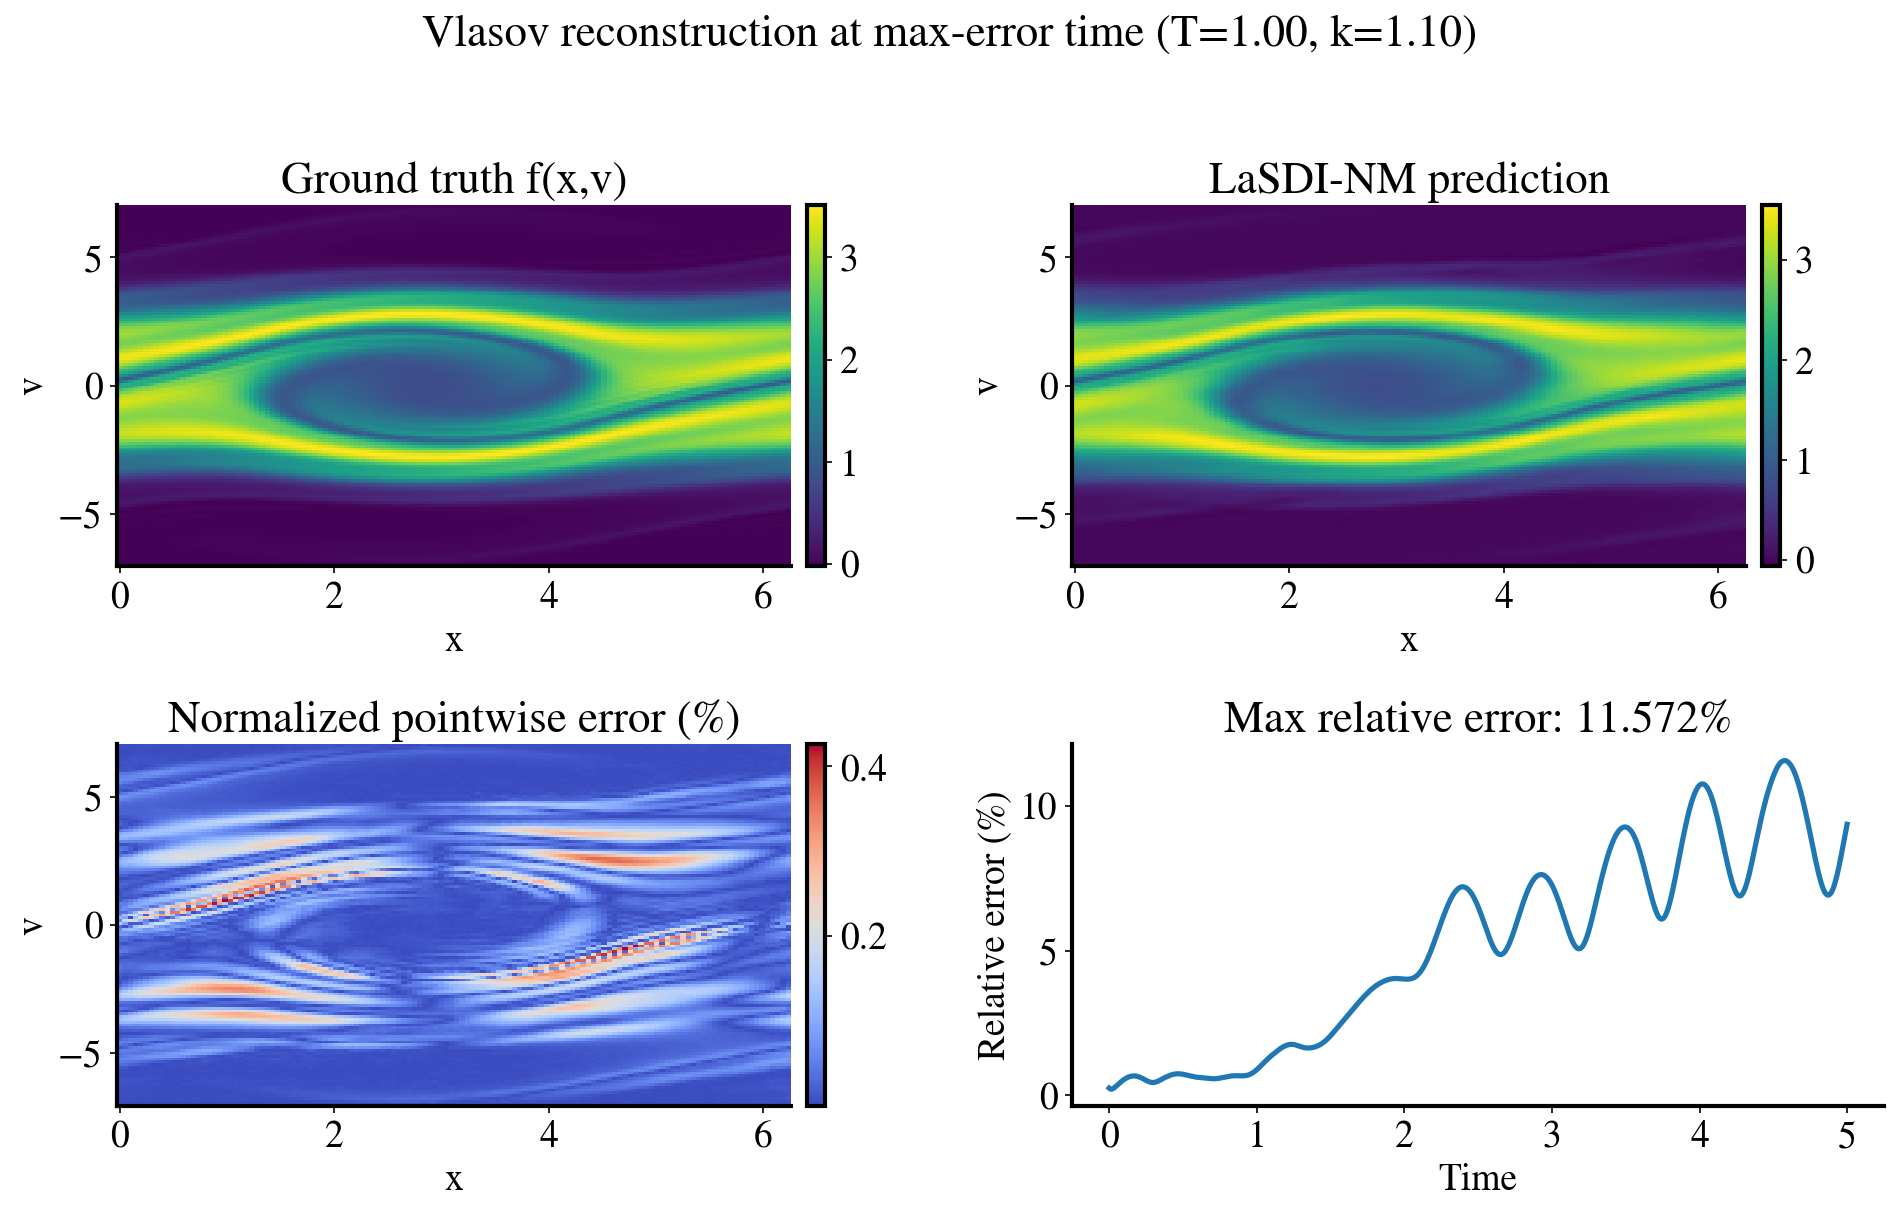

In [73]:
k_max = int(np.argmax(result_eval['rel_t']))

X, V = np.meshgrid(result_eval['x'], result_eval['v'], indexing='xy')
true_snapshot = result_eval['f_true'][k_max]
pred_snapshot = result_eval['f_pred'][k_max]
field_err = np.abs(pred_snapshot - true_snapshot)
field_err /= max(LA.norm(true_snapshot), 1.0e-12)

fig = plt.figure(figsize=(13, 8))
fig.suptitle(
    f"Vlasov reconstruction at max-error time (T={result_eval['T']:.2f}, k={result_eval['k']:.2f})",
    y=1.02,
)

ax1 = fig.add_subplot(2, 2, 1)
z1 = ax1.pcolormesh(X, V, true_snapshot.T, shading='auto')
fig.colorbar(z1, ax=ax1, pad=0.02)
ax1.set_title('Ground truth f(x,v)')
ax1.set_xlabel('x')
ax1.set_ylabel('v')

ax2 = fig.add_subplot(2, 2, 2)
z2 = ax2.pcolormesh(X, V, pred_snapshot.T, shading='auto')
fig.colorbar(z2, ax=ax2, pad=0.02)
ax2.set_title('LaSDI-NM prediction')
ax2.set_xlabel('x')
ax2.set_ylabel('v')

ax3 = fig.add_subplot(2, 2, 3)
z3 = ax3.pcolormesh(X, V, field_err.T * 100.0, shading='auto', cmap='coolwarm')
fig.colorbar(z3, ax=ax3, pad=0.02)
ax3.set_title('Normalized pointwise error (%)')
ax3.set_xlabel('x')
ax3.set_ylabel('v')

ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(result_eval['t'], 100.0 * result_eval['rel_t'])
ax4.set_xlabel('Time')
ax4.set_ylabel('Relative error (%)')
ax4.set_title(f"Max relative error: {100.0*np.max(result_eval['rel_t']):.3f}%")

fig.tight_layout()
plt.show()


## Error Map on Full 21x21 Grid (441 cases)


[error-map-convae] processed 25/441  elapsed=60.5s
[error-map-convae] processed 50/441  elapsed=119.0s
[error-map-convae] processed 75/441  elapsed=178.9s
[error-map-convae] processed 100/441  elapsed=238.8s
[error-map-convae] processed 125/441  elapsed=296.8s
[error-map-convae] processed 150/441  elapsed=353.1s
[error-map-convae] processed 175/441  elapsed=408.8s
[error-map-convae] processed 200/441  elapsed=461.7s
[error-map-convae] processed 225/441  elapsed=514.3s
[error-map-convae] processed 250/441  elapsed=567.6s
[error-map-convae] processed 275/441  elapsed=618.8s
[error-map-convae] processed 300/441  elapsed=668.7s
[error-map-convae] processed 325/441  elapsed=719.5s
[error-map-convae] processed 350/441  elapsed=768.7s
[error-map-convae] processed 375/441  elapsed=819.4s
[error-map-convae] processed 400/441  elapsed=868.1s
[error-map-convae] processed 425/441  elapsed=916.6s
[error-map-convae] processed 441/441  elapsed=947.5s


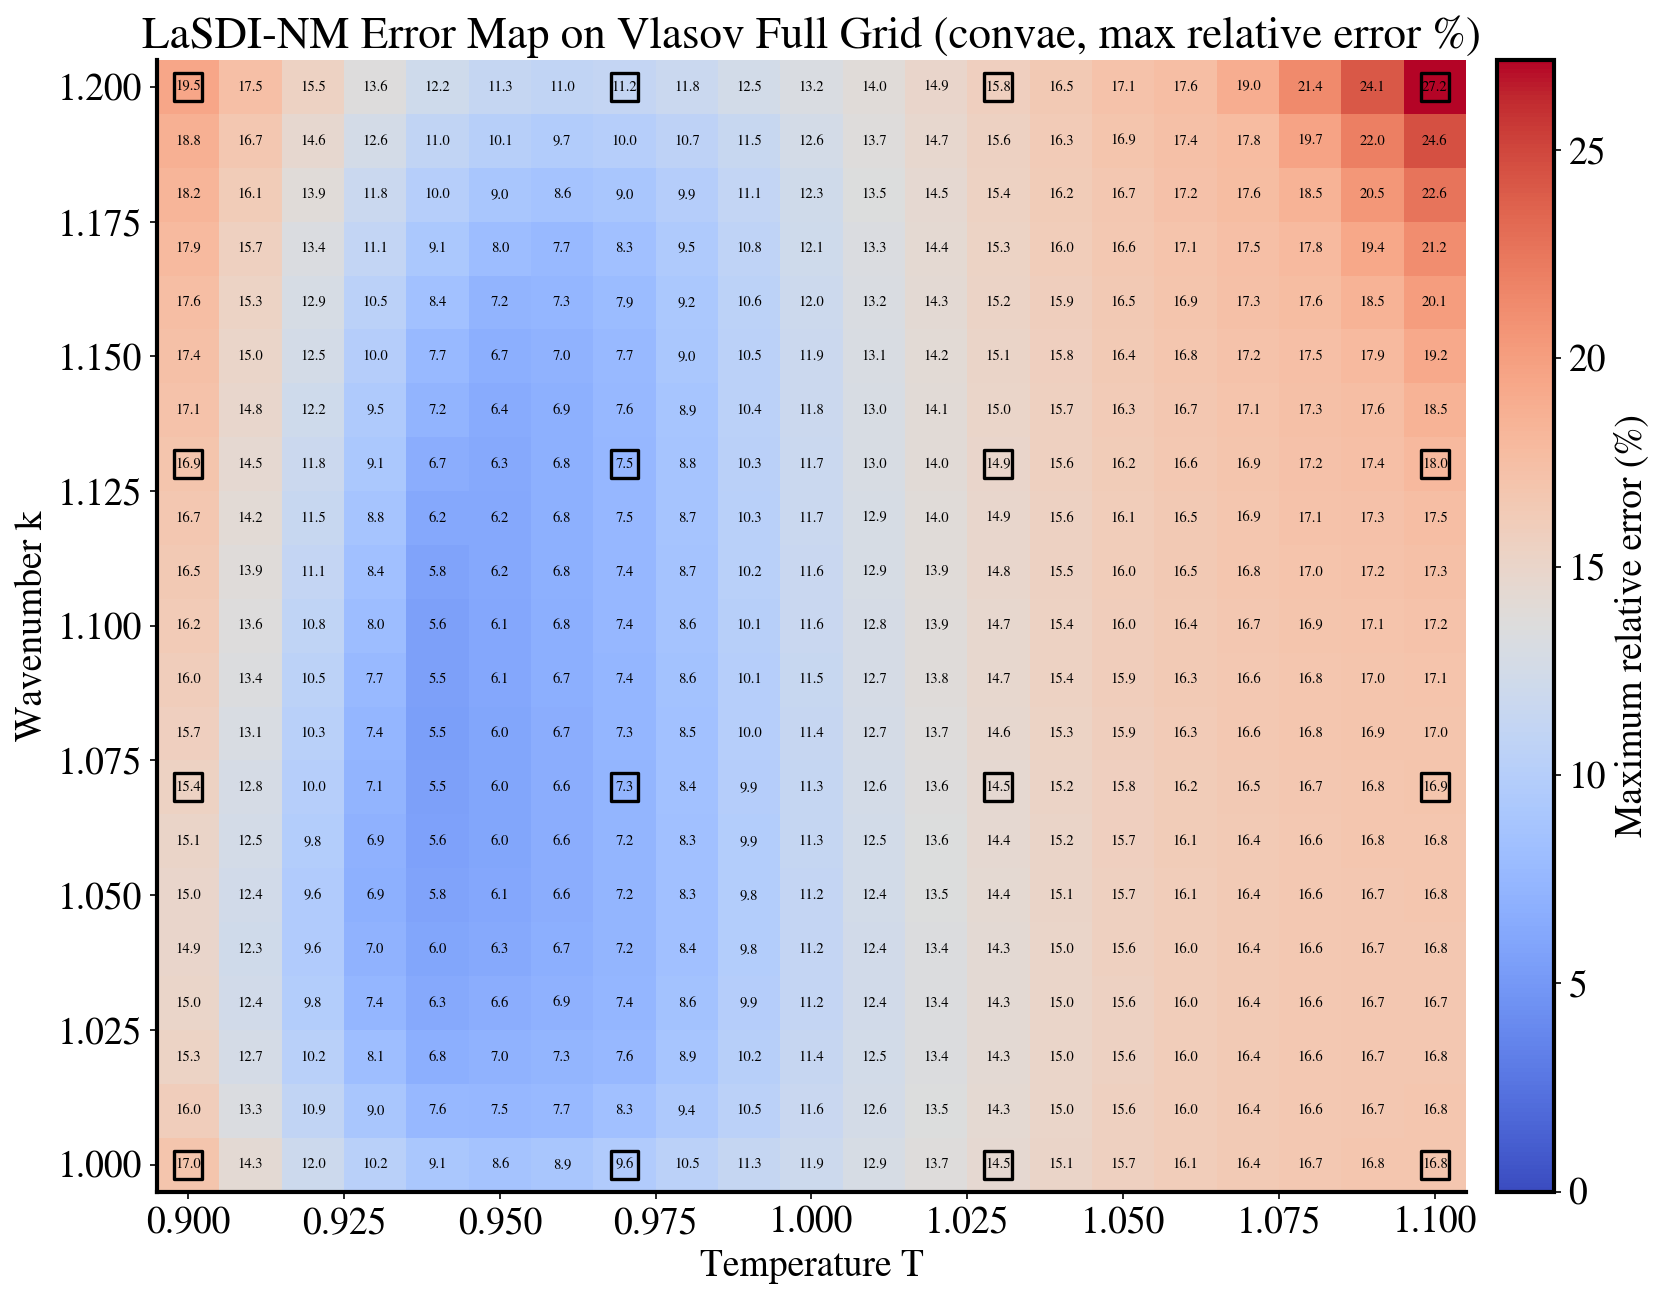

Saved error map image to: /home/uts22/projects/ML_phisycs/LaSDI/Vlasov_twostream/results/lasdi_vlasov_error_map_full_grid_convae.png
Saved error map data  to: /home/uts22/projects/ML_phisycs/LaSDI/Vlasov_twostream/results/lasdi_vlasov_error_map_full_grid_convae.npz


In [74]:
# For faster execution, use time_stride>1.
error_map_time_stride = 1

params_all = np.asarray([[c['T'], c['k']] for c in all_cases], dtype=float)
T_values = np.sort(np.unique(params_all[:, 0]))
k_values = np.sort(np.unique(params_all[:, 1]))

T_index = {float(T): j for j, T in enumerate(T_values)}
k_index = {float(k): i for i, k in enumerate(k_values)}
error_grid = np.full((k_values.size, T_values.size), np.nan, dtype=float)

start = time.time()
failed_cases = []
for idx, case in enumerate(all_cases, start=1):
    try:
        result = reconstruct_case(
            case['T'],
            case['k'],
            time_stride=error_map_time_stride,
        )
        err_percent = 100.0 * np.max(result['rel_t'])
        error_grid[k_index[float(case['k'])], T_index[float(case['T'])]] = err_percent
    except Exception as exc:
        failed_cases.append((float(case['T']), float(case['k']), str(exc)))
        error_grid[k_index[float(case['k'])], T_index[float(case['T'])]] = np.nan

    if idx % 25 == 0 or idx == len(all_cases):
        elapsed = time.time() - start
        print(f'[error-map-{model_tag}] processed {idx}/{len(all_cases)}  elapsed={elapsed:.1f}s')

if failed_cases:
    print(f'[error-map-{model_tag}] failed cases: {len(failed_cases)}')
    print(f'[error-map-{model_tag}] first failure:', failed_cases[0])


def _cell_edges(values):
    if values.size == 1:
        v0 = float(values[0])
        return np.array([v0 - 0.5, v0 + 0.5], dtype=float)
    mids = 0.5 * (values[:-1] + values[1:])
    left = values[0] - 0.5 * (values[1] - values[0])
    right = values[-1] + 0.5 * (values[-1] - values[-2])
    return np.concatenate([[left], mids, [right]])


def _select_training_params(T_vals, k_vals, samples_per_axis_local):
    if samples_per_axis_local <= 0:
        raise ValueError('samples_per_axis_local must be positive')
    if samples_per_axis_local > len(T_vals) or samples_per_axis_local > len(k_vals):
        raise ValueError('samples_per_axis_local exceeds available grid size')

    T_idx = np.round(np.linspace(0, len(T_vals) - 1, samples_per_axis_local)).astype(int)
    k_idx = np.round(np.linspace(0, len(k_vals) - 1, samples_per_axis_local)).astype(int)
    T_idx = np.asarray(list(dict.fromkeys(T_idx.tolist())), dtype=int)
    k_idx = np.asarray(list(dict.fromkeys(k_idx.tolist())), dtype=int)

    train_params = np.array(
        [(float(T_vals[i]), float(k_vals[j])) for i in T_idx for j in k_idx],
        dtype=float,
    )
    return train_params


T_edges = _cell_edges(T_values)
k_edges = _cell_edges(k_values)

fig, ax = plt.subplots(figsize=(12, 9))
mesh = ax.pcolormesh(
    T_edges,
    k_edges,
    error_grid,
    shading='auto',
    cmap='coolwarm',
    vmin=0.0,
    vmax=float(np.nanmax(error_grid) if np.any(~np.isnan(error_grid)) else 1.0),
)

for i, k in enumerate(k_values):
    for j, T in enumerate(T_values):
        value = error_grid[i, j]
        if np.isnan(value):
            continue
        ax.text(float(T), float(k), f'{value:.1f}', ha='center', va='center', fontsize=7, color='black')

train_params = _select_training_params(T_values, k_values, samples_per_axis_local=samples_per_axis)
ax.scatter(
    train_params[:, 0],
    train_params[:, 1],
    marker='s',
    s=180,
    facecolors='none',
    edgecolors='black',
    linewidths=1.6,
)

ax.set_xlabel('Temperature T')
ax.set_ylabel('Wavenumber k')
ax.set_title(f'LaSDI-NM Error Map on Vlasov Full Grid ({model_tag}, max relative error %)')

cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label('Maximum relative error (%)')
fig.tight_layout()

out_dir = Path('results')
out_dir.mkdir(parents=True, exist_ok=True)
out_img = out_dir / f'lasdi_vlasov_error_map_full_grid_{model_tag}.png'
out_npz = out_dir / f'lasdi_vlasov_error_map_full_grid_{model_tag}.npz'
fig.savefig(out_img, dpi=300)
np.savez(
    out_npz,
    T_values=T_values,
    k_values=k_values,
    max_rel_err_percent=error_grid,
    train_params=train_params,
    eval_params=params_all,
    time_stride=np.array([error_map_time_stride], dtype=int),
)
plt.show()

print(f'Saved error map image to: {out_img.resolve()}')
print(f'Saved error map data  to: {out_npz.resolve()}')


## AE Reconstruction Error Map on Full 21x21 Grid (ConvAE / FlatAE)


[ae-error-map-convae] processed 25/441  elapsed=12.9s
[ae-error-map-convae] processed 50/441  elapsed=25.7s
[ae-error-map-convae] processed 75/441  elapsed=37.3s
[ae-error-map-convae] processed 100/441  elapsed=50.1s
[ae-error-map-convae] processed 125/441  elapsed=61.8s
[ae-error-map-convae] processed 150/441  elapsed=74.6s
[ae-error-map-convae] processed 175/441  elapsed=87.4s
[ae-error-map-convae] processed 200/441  elapsed=99.3s
[ae-error-map-convae] processed 225/441  elapsed=111.8s
[ae-error-map-convae] processed 250/441  elapsed=124.7s
[ae-error-map-convae] processed 275/441  elapsed=136.2s
[ae-error-map-convae] processed 300/441  elapsed=149.1s
[ae-error-map-convae] processed 325/441  elapsed=160.8s
[ae-error-map-convae] processed 350/441  elapsed=173.8s
[ae-error-map-convae] processed 375/441  elapsed=186.6s
[ae-error-map-convae] processed 400/441  elapsed=198.7s
[ae-error-map-convae] processed 425/441  elapsed=211.8s
[ae-error-map-convae] processed 441/441  elapsed=219.9s


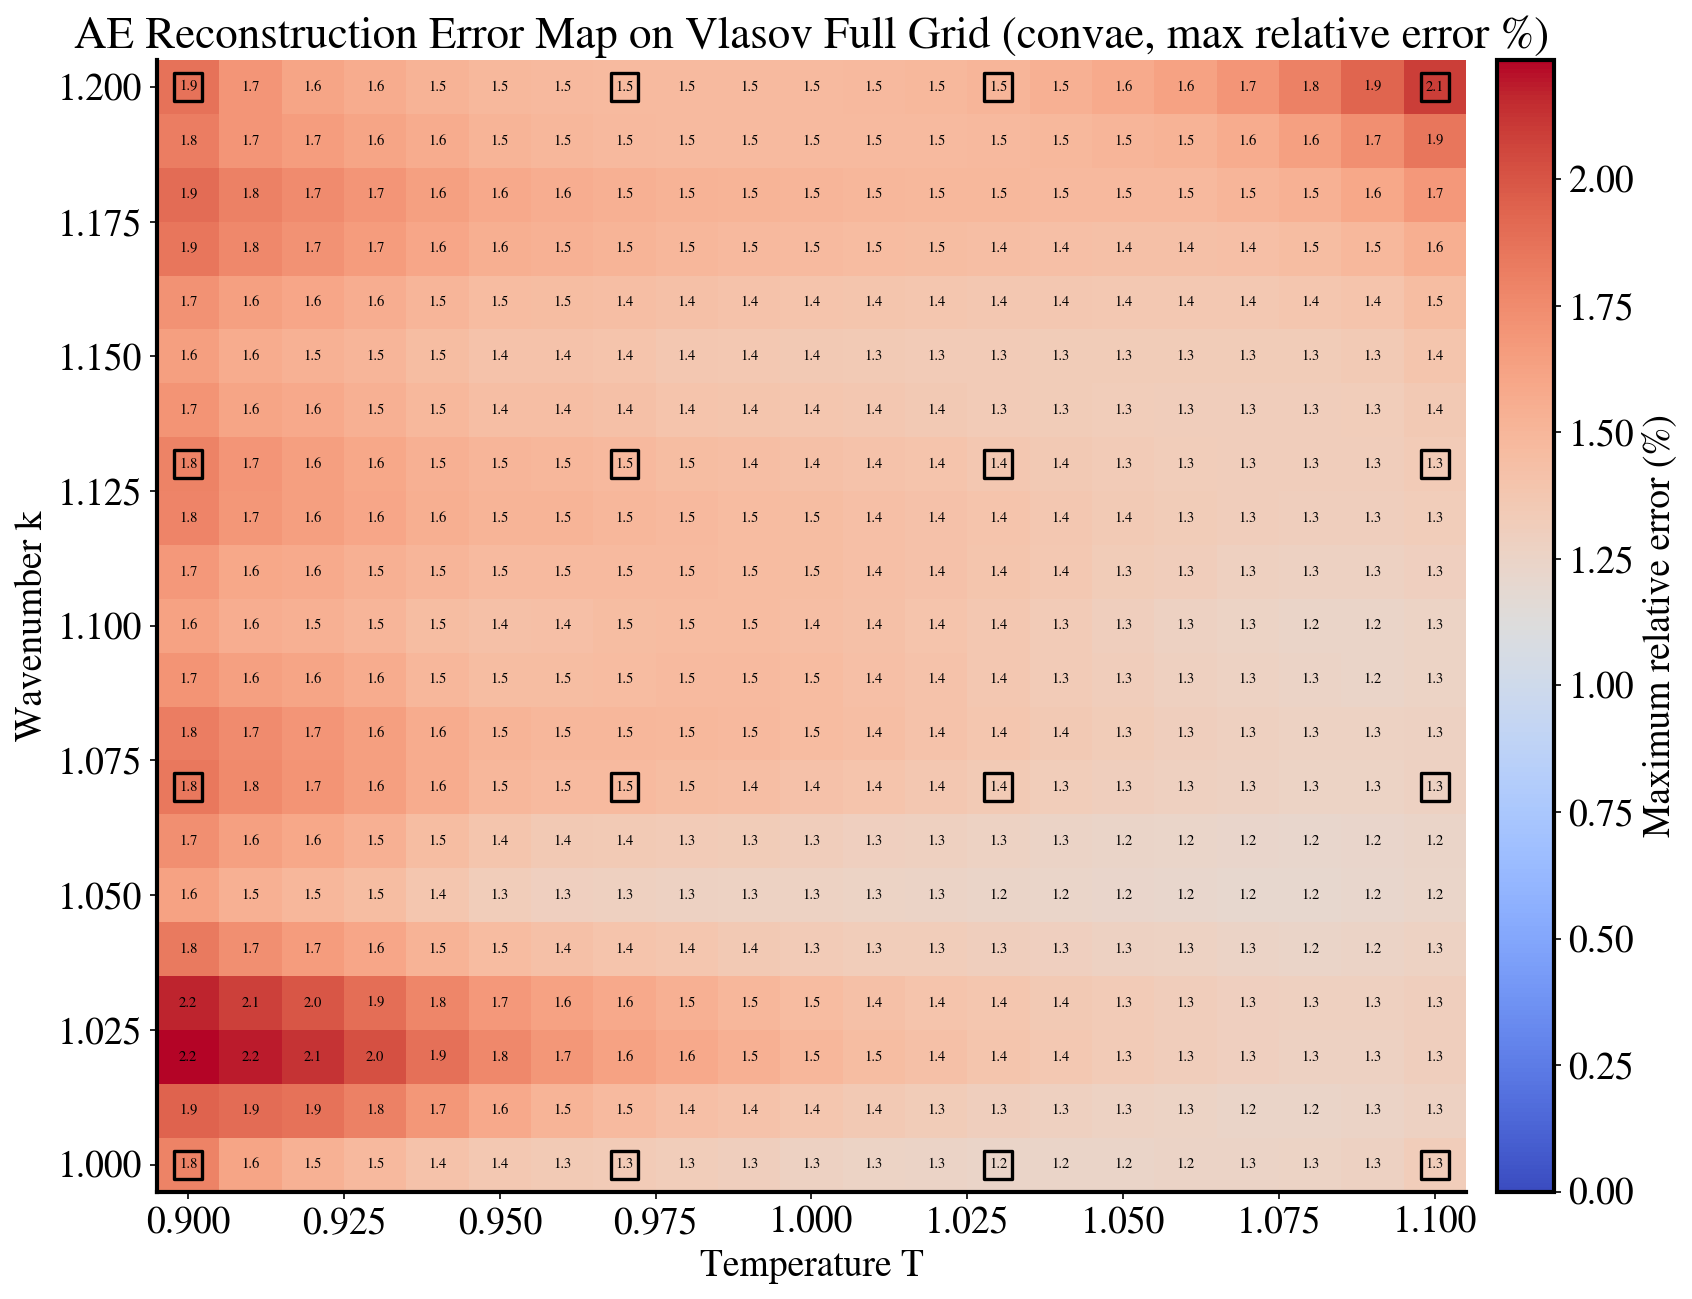

Saved AE error map image to: /home/uts22/projects/ML_phisycs/LaSDI/Vlasov_twostream/results/ae_reconstruction_error_map_full_grid_convae.png
Saved AE error map data  to: /home/uts22/projects/ML_phisycs/LaSDI/Vlasov_twostream/results/ae_reconstruction_error_map_full_grid_convae.npz
AE error range: min=1.208%, max=2.236%


In [75]:
# AE-only error map (no SINDy rollout): x -> encoder -> decoder -> x_hat
# For faster execution, increase ae_error_map_time_stride.
ae_error_map_time_stride = 1
ae_batch_size = 256


def ae_reconstruct_case(T, k, time_stride=1, batch_size=256):
    key = (round(float(T), 2), round(float(k), 2))
    if key not in case_map:
        raise KeyError(f'Case T={T}, k={k} is not available in dataset')

    with np.load(case_map[key]['path']) as data:
        f_true_full = np.asarray(data['f'], dtype=np.float32)
        t_full = np.asarray(data['t'], dtype=float)

    stride = max(1, int(time_stride))
    time_indices = np.arange(0, len(t_full), stride, dtype=int)
    t_eval = t_full[time_indices]
    f_true = f_true_full[time_indices]

    z = encode_field_sequence(f_true, batch_size=batch_size)
    f_pred = decode_latent_sequence(z, batch_size=batch_size)

    if not np.all(np.isfinite(f_pred)):
        raise FloatingPointError(
            f'Non-finite AE reconstruction for T={float(T):.2f}, k={float(k):.2f}'
        )

    n_t = min(f_true.shape[0], f_pred.shape[0])
    f_true = f_true[:n_t]
    t_eval = t_eval[:n_t]
    f_pred = f_pred[:n_t]

    true_flat = f_true.reshape(n_t, -1)
    pred_flat = f_pred.reshape(n_t, -1)
    denom = np.maximum(np.linalg.norm(true_flat, axis=1), 1.0e-12)
    rel_t = np.linalg.norm(pred_flat - true_flat, axis=1) / denom

    return {
        'T': float(T),
        'k': float(k),
        't': t_eval,
        'f_true': f_true,
        'f_pred': f_pred,
        'rel_t': rel_t,
    }


params_all = np.asarray([[c['T'], c['k']] for c in all_cases], dtype=float)
T_values = np.sort(np.unique(params_all[:, 0]))
k_values = np.sort(np.unique(params_all[:, 1]))
T_index = {float(T): j for j, T in enumerate(T_values)}
k_index = {float(k): i for i, k in enumerate(k_values)}
ae_error_grid = np.full((k_values.size, T_values.size), np.nan, dtype=float)

start = time.time()
failed_cases_ae = []
for idx, case in enumerate(all_cases, start=1):
    try:
        result = ae_reconstruct_case(
            case['T'],
            case['k'],
            time_stride=ae_error_map_time_stride,
            batch_size=ae_batch_size,
        )
        err_percent = 100.0 * np.max(result['rel_t'])
        ae_error_grid[k_index[float(case['k'])], T_index[float(case['T'])]] = err_percent
    except Exception as exc:
        failed_cases_ae.append((float(case['T']), float(case['k']), str(exc)))
        ae_error_grid[k_index[float(case['k'])], T_index[float(case['T'])]] = np.nan

    if idx % 25 == 0 or idx == len(all_cases):
        elapsed = time.time() - start
        print(f'[ae-error-map-{model_tag}] processed {idx}/{len(all_cases)}  elapsed={elapsed:.1f}s')

if failed_cases_ae:
    print(f'[ae-error-map-{model_tag}] failed cases: {len(failed_cases_ae)}')
    print(f'[ae-error-map-{model_tag}] first failure:', failed_cases_ae[0])


def _cell_edges(values):
    if values.size == 1:
        v0 = float(values[0])
        return np.array([v0 - 0.5, v0 + 0.5], dtype=float)
    mids = 0.5 * (values[:-1] + values[1:])
    left = values[0] - 0.5 * (values[1] - values[0])
    right = values[-1] + 0.5 * (values[-1] - values[-2])
    return np.concatenate([[left], mids, [right]])


T_edges = _cell_edges(T_values)
k_edges = _cell_edges(k_values)

fig, ax = plt.subplots(figsize=(12, 9))
mesh = ax.pcolormesh(
    T_edges,
    k_edges,
    ae_error_grid,
    shading='auto',
    cmap='coolwarm',
    vmin=0.0,
    vmax=float(np.nanmax(ae_error_grid) if np.any(~np.isnan(ae_error_grid)) else 1.0),
)

for i, k in enumerate(k_values):
    for j, T in enumerate(T_values):
        value = ae_error_grid[i, j]
        if np.isnan(value):
            continue
        ax.text(float(T), float(k), f'{value:.1f}', ha='center', va='center', fontsize=7, color='black')

train_params = np.asarray([[c['T'], c['k']] for c in train_cases], dtype=float)
ax.scatter(
    train_params[:, 0],
    train_params[:, 1],
    marker='s',
    s=180,
    facecolors='none',
    edgecolors='black',
    linewidths=1.6,
)

ax.set_xlabel('Temperature T')
ax.set_ylabel('Wavenumber k')
ax.set_title(f'AE Reconstruction Error Map on Vlasov Full Grid ({model_tag}, max relative error %)')

cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
cbar.set_label('Maximum relative error (%)')
fig.tight_layout()

out_dir = Path('results')
out_dir.mkdir(parents=True, exist_ok=True)
out_img = out_dir / f'ae_reconstruction_error_map_full_grid_{model_tag}.png'
out_npz = out_dir / f'ae_reconstruction_error_map_full_grid_{model_tag}.npz'
fig.savefig(out_img, dpi=300)
np.savez(
    out_npz,
    T_values=T_values,
    k_values=k_values,
    max_rel_err_percent=ae_error_grid,
    train_params=train_params,
    eval_params=params_all,
    time_stride=np.array([ae_error_map_time_stride], dtype=int),
    batch_size=np.array([ae_batch_size], dtype=int),
)
plt.show()

print(f'Saved AE error map image to: {out_img.resolve()}')
print(f'Saved AE error map data  to: {out_npz.resolve()}')
if np.any(~np.isnan(ae_error_grid)):
    print(f"AE error range: min={np.nanmin(ae_error_grid):.3f}%, max={np.nanmax(ae_error_grid):.3f}%")
